In [9]:
import os
import pandas as pd

# Define input folder
input_folder = "Attribution Scores 1.5B Original"

# Initialize list to collect statistics
stats_list = []

# Loop over all CSVs in the folder
for filename in os.listdir(input_folder):
    if filename.endswith(".csv") and filename.startswith("MedBullets_df_op4_Q"):
        filepath = os.path.join(input_folder, filename)
        
        try:
            df = pd.read_csv(filepath)

            # Check if necessary columns exist
            if "Score" in df.columns and "Extracted_Answer" in df.columns:
                mean_score = df["Score"].mean()
                std_score = df["Score"].std()
                extracted_answer = df["Extracted_Answer"].dropna().astype(str).iloc[0] if not df["Extracted_Answer"].dropna().empty else None

                stats_list.append({
                    "QA_ID": filename.replace(".csv", ""),
                    "Mean_Score": mean_score,
                    "Std_Score": std_score,
                    "Extracted_Answer": extracted_answer
                })
            else:
                print(f"⚠️ Skipped {filename} (missing 'Score' or 'Extracted_Answer' column)")

        except Exception as e:
            print(f"❌ Error processing {filename}: {e}")

# Create summary DataFrame
stats_df = pd.DataFrame(stats_list)

# Display the first few rows
stats_df.head(30)
print(len(stats_df))

298


In [2]:
# Add new columns: 1 std above and below the mean
stats_df["Upper_Threshold"] = stats_df["Mean_Score"] + stats_df["Std_Score"]
stats_df["Lower_Threshold"] = stats_df["Mean_Score"] - stats_df["Std_Score"]

# Display updated DataFrame
stats_df.head()


,QA_ID,Mean_Score,Std_Score,Extracted_Answer,Upper_Threshold,Lower_Threshold
0,MedBullets_df_op4_Q60,44.281328,37.335040,C,81.616369,6.946288
1,MedBullets_df_op4_Q207,31.728566,27.782369,C,59.510935,3.946197
2,MedBullets_df_op4_Q110,19.250953,26.856555,B,46.107508,-7.605603
3,MedBullets_df_op4_Q200,22.440794,20.645107,A,43.085901,1.795687
4,MedBullets_df_op4_Q117,34.064683,26.895311,A,60.959995,7.169372


In [10]:
import os
import pandas as pd

# Initialize relevance columns with zero
stats_df["Highly Relevant"] = 0
stats_df["Low Relevant"] = 0
stats_df["Irrelevant"] = 0

# Define input directory
input_folder = "Attribution Scores 1.5B Original"

# Process each QA file and compute relevance categories
for i, row in stats_df.iterrows():
    qa_id = row["QA_ID"]
    file_path = os.path.join(input_folder, f"{qa_id}.csv")

    try:
        df = pd.read_csv(file_path)

        if "Score" in df.columns:
            scores = df["Score"]

            # Count relevance categories based on thresholds
            high_count = (scores > row["Upper_Threshold"]).sum()
            low_count = ((scores >= row["Lower_Threshold"]) & (scores <= row["Upper_Threshold"]) & (scores != 0)).sum()
            zero_count = (scores == 0).sum()

            # Update stats_df with raw counts
            stats_df.at[i, "Highly Relevant"] = high_count
            stats_df.at[i, "Low Relevant"] = low_count
            stats_df.at[i, "Irrelevant"] = zero_count
        else:
            print(f"⚠️ Skipped {qa_id}.csv — 'Score' column not found.")

    except Exception as e:
        print(f"❌ Error processing {qa_id}.csv: {e}")

# Normalize counts into proportions
relevance_cols = ["Highly Relevant", "Low Relevant", "Irrelevant"]
relevance_totals = stats_df[relevance_cols].sum(axis=1)

for col in relevance_cols:
    stats_df[col] = stats_df[col] / relevance_totals

# Preview results
stats_df.head(5)


❌ Error processing MedBullets_df_op4_Q60.csv: 'Upper_Threshold'
❌ Error processing MedBullets_df_op4_Q207.csv: 'Upper_Threshold'
❌ Error processing MedBullets_df_op4_Q110.csv: 'Upper_Threshold'
❌ Error processing MedBullets_df_op4_Q200.csv: 'Upper_Threshold'
❌ Error processing MedBullets_df_op4_Q117.csv: 'Upper_Threshold'
❌ Error processing MedBullets_df_op4_Q67.csv: 'Upper_Threshold'
❌ Error processing MedBullets_df_op4_Q119.csv: 'Upper_Threshold'
❌ Error processing MedBullets_df_op4_Q15.csv: 'Upper_Threshold'
❌ Error processing MedBullets_df_op4_Q272.csv: 'Upper_Threshold'
❌ Error processing MedBullets_df_op4_Q165.csv: 'Upper_Threshold'
❌ Error processing MedBullets_df_op4_Q69.csv: 'Upper_Threshold'
❌ Error processing MedBullets_df_op4_Q275.csv: 'Upper_Threshold'
❌ Error processing MedBullets_df_op4_Q162.csv: 'Upper_Threshold'
❌ Error processing MedBullets_df_op4_Q209.csv: 'Upper_Threshold'
❌ Error processing MedBullets_df_op4_Q12.csv: 'Upper_Threshold'
❌ Error processing MedBullets_

❌ Error processing MedBullets_df_op4_Q268.csv: 'Upper_Threshold'
❌ Error processing MedBullets_df_op4_Q103.csv: 'Upper_Threshold'
❌ Error processing MedBullets_df_op4_Q214.csv: 'Upper_Threshold'
❌ Error processing MedBullets_df_op4_Q171.csv: 'Upper_Threshold'
❌ Error processing MedBullets_df_op4_Q266.csv: 'Upper_Threshold'
❌ Error processing MedBullets_df_op4_Q3.csv: 'Upper_Threshold'
❌ Error processing MedBullets_df_op4_Q4.csv: 'Upper_Threshold'
❌ Error processing MedBullets_df_op4_Q176.csv: 'Upper_Threshold'
❌ Error processing MedBullets_df_op4_Q261.csv: 'Upper_Threshold'
❌ Error processing MedBullets_df_op4_Q228.csv: 'Upper_Threshold'
❌ Error processing MedBullets_df_op4_Q33.csv: 'Upper_Threshold'
❌ Error processing MedBullets_df_op4_Q254.csv: 'Upper_Threshold'
❌ Error processing MedBullets_df_op4_Q192.csv: 'Upper_Threshold'
❌ Error processing MedBullets_df_op4_Q143.csv: 'Upper_Threshold'
❌ Error processing MedBullets_df_op4_Q285.csv: 'Upper_Threshold'
❌ Error processing MedBullets_

,QA_ID,Mean_Score,Std_Score,Extracted_Answer,Highly Relevant,Low Relevant,Irrelevant
0,MedBullets_df_op4_Q60,44.281328,37.335040,C,NaN,NaN,NaN
1,MedBullets_df_op4_Q207,31.728566,27.782369,C,NaN,NaN,NaN
2,MedBullets_df_op4_Q110,19.250953,26.856555,B,NaN,NaN,NaN
3,MedBullets_df_op4_Q200,22.440794,20.645107,A,NaN,NaN,NaN
4,MedBullets_df_op4_Q117,34.064683,26.895311,A,NaN,NaN,NaN


In [11]:
std_score = stats_df["Mean_Score"].std()
print(f"Standard Deviation of Mean_Score: {std_score}")

mean_score=stats_df["Mean_Score"].mean()
print(f"Mean of Mean_Score: {mean_score}")


Standard Deviation of Mean_Score: 14.273038224524978
Mean of Mean_Score: 29.243294173277725


In [12]:
# Reshape the DataFrame for analysis
df_long = stats_df[["Highly Relevant", "Low Relevant", "Irrelevant"]].reset_index().melt(
    id_vars="index", 
    var_name="RelevanceCategory", 
    value_name="Proportion"
)
df_long = df_long.rename(columns={"index": "Subject"})

import statsmodels.api as sm
from statsmodels.formula.api import ols

# Fit the repeated-measures ANOVA model
model = ols("Proportion ~ C(RelevanceCategory) + C(Subject)", data=df_long).fit()
anova_results = sm.stats.anova_lm(model, typ=2)
print(anova_results)

from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(endog=df_long["Proportion"],
                          groups=df_long["RelevanceCategory"],
                          alpha=0.05)
print(tukey)


ValueError: zero-size array to reduction operation maximum which has no identity

/tmp/ipykernel_871852/196489525.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, patch_artist=True, labels=labels, widths=0.6)


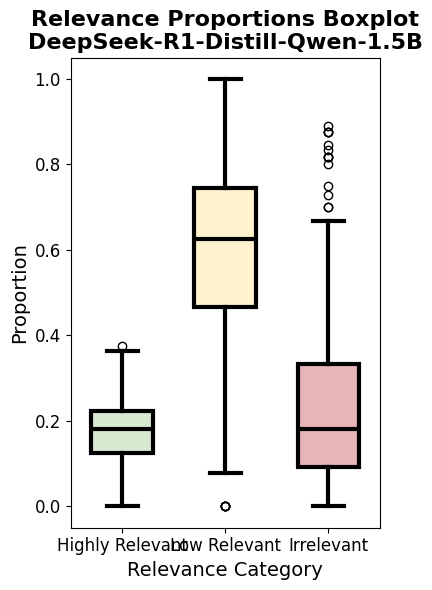

In [5]:
import matplotlib.pyplot as plt

# HEX colors sampled from your visual legend
color_high = "#d9ead3"        # Highly Relevant
color_low = "#fff2cc"         # Low Relevant
color_irrel = "#e8b4b8"       # Irrelevant

# Prepare the data
data = [
    stats_df["Highly Relevant"].dropna(),
    stats_df["Low Relevant"].dropna(),
    stats_df["Irrelevant"].dropna()
]

labels = ["Highly Relevant", "Low Relevant", "Irrelevant"]
colors = [color_high, color_low, color_irrel]

# Create the boxplot
fig, ax = plt.subplots(figsize=(4, 6))
bp = ax.boxplot(data, patch_artist=True, labels=labels, widths=0.6)

# Apply colors and formatting
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_linewidth(3)

for whisker in bp["whiskers"]:
    whisker.set_linewidth(3)
for cap in bp["caps"]:
    cap.set_linewidth(3)
for median in bp["medians"]:
    median.set_linewidth(3)
    median.set_color("black")

# Customize text and layout
ax.set_title("Relevance Proportions Boxplot\nDeepSeek-R1-Distill-Qwen-1.5B", fontsize=16, weight='bold')
ax.set_ylabel("Proportion", fontsize=14)
ax.set_xlabel("Relevance Category", fontsize=14)
ax.tick_params(axis='both', labelsize=12)

# Export
plt.tight_layout()
plt.savefig("qwen1.5b_relevance_boxplot_colored.pdf", dpi=300)
plt.show()


## Compare the Results

In [13]:
# Load the medbullets ground truth file
truth_df = pd.read_csv("medbullets_4o_reasoning_results.csv")

# Strip and upper-case for reliable comparison
truth_df["answer_idx"] = truth_df["answer_idx"].astype(str).str.strip().str.upper()
stats_df["Extracted_Answer"] = stats_df["Extracted_Answer"].astype(str).str.strip().str.upper()

# Extract numeric index from QA_ID
stats_df["QA_Index"] = stats_df["QA_ID"].str.extract(r"Q(\d+)", expand=False).astype(int) - 1  # 0-based indexing

# Map ground truth answer
stats_df["Ground_Truth_Answer"] = stats_df["QA_Index"].map(truth_df["answer_idx"])

# Mark match status (will still include 'NONE' for now)
stats_df["Answer_Match"] = stats_df["Extracted_Answer"] == stats_df["Ground_Truth_Answer"]

# Exclude rows where Extracted_Answer is "NONE" from accuracy calculation
valid_mask = stats_df["Extracted_Answer"].str.upper() != "NONE"
valid_answers = stats_df[valid_mask]
excluded_count = len(stats_df) - len(valid_answers)

# Calculate and print accuracy
accuracy = (valid_answers["Extracted_Answer"] == valid_answers["Ground_Truth_Answer"]).mean()
print(f"Accuracy (excluding 'NONE'): {accuracy * 100:.1f}%")
print(f"Excluded {excluded_count} rows with 'Extracted_Answer' as 'NONE'.")

# Preview mismatches (optional)
mismatches = valid_answers[valid_answers["Answer_Match"] == False]

# Sort by QA number
stats_df_sorted = stats_df.sort_values("QA_Index").reset_index(drop=True)

# Display top rows
stats_df_sorted.head(5)


Accuracy (excluding 'NONE'): 22.8%
Excluded 66 rows with 'Extracted_Answer' as 'NONE'.


,QA_ID,Mean_Score,Std_Score,Extracted_Answer,Highly Relevant,Low Relevant,Irrelevant,QA_Index,Ground_Truth_Answer,Answer_Match
0,MedBullets_df_op4_Q1,7.152861,10.115673,D,NaN,NaN,NaN,0,C,False
1,MedBullets_df_op4_Q2,23.807183,25.136285,D,NaN,NaN,NaN,1,B,False
2,MedBullets_df_op4_Q3,24.553307,26.443072,NONE,NaN,NaN,NaN,2,A,False
3,MedBullets_df_op4_Q4,29.424077,22.210440,A,NaN,NaN,NaN,3,D,False
4,MedBullets_df_op4_Q5,26.995228,31.581395,C,NaN,NaN,NaN,4,A,False


/tmp/ipykernel_871852/4247609899.py:40: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = combined_df.groupby(bin_centers)["Score"]


⚠️ Skipped MedBullets_df_op4_Q1.csv (missing Score or sentence_ID)
⚠️ Skipped MedBullets_df_op4_Q100.csv (missing Score or sentence_ID)
⚠️ Skipped MedBullets_df_op4_Q101.csv (missing Score or sentence_ID)
⚠️ Skipped MedBullets_df_op4_Q102.csv (missing Score or sentence_ID)
⚠️ Skipped MedBullets_df_op4_Q103.csv (missing Score or sentence_ID)
⚠️ Skipped MedBullets_df_op4_Q104.csv (missing Score or sentence_ID)
⚠️ Skipped MedBullets_df_op4_Q105.csv (missing Score or sentence_ID)
⚠️ Skipped MedBullets_df_op4_Q106.csv (missing Score or sentence_ID)
⚠️ Skipped MedBullets_df_op4_Q107.csv (missing Score or sentence_ID)
⚠️ Skipped MedBullets_df_op4_Q108.csv (missing Score or sentence_ID)
⚠️ Skipped MedBullets_df_op4_Q109.csv (missing Score or sentence_ID)
⚠️ Skipped MedBullets_df_op4_Q11.csv (missing Score or sentence_ID)
⚠️ Skipped MedBullets_df_op4_Q110.csv (missing Score or sentence_ID)
⚠️ Skipped MedBullets_df_op4_Q111.csv (missing Score or sentence_ID)
⚠️ Skipped MedBullets_df_op4_Q112.csv

⚠️ Skipped MedBullets_df_op4_Q212.csv (missing Score or sentence_ID)
⚠️ Skipped MedBullets_df_op4_Q213.csv (missing Score or sentence_ID)
⚠️ Skipped MedBullets_df_op4_Q214.csv (missing Score or sentence_ID)
⚠️ Skipped MedBullets_df_op4_Q215.csv (missing Score or sentence_ID)
⚠️ Skipped MedBullets_df_op4_Q216.csv (missing Score or sentence_ID)
⚠️ Skipped MedBullets_df_op4_Q217.csv (missing Score or sentence_ID)
⚠️ Skipped MedBullets_df_op4_Q219.csv (missing Score or sentence_ID)
⚠️ Skipped MedBullets_df_op4_Q22.csv (missing Score or sentence_ID)
⚠️ Skipped MedBullets_df_op4_Q220.csv (missing Score or sentence_ID)
⚠️ Skipped MedBullets_df_op4_Q221.csv (missing Score or sentence_ID)
⚠️ Skipped MedBullets_df_op4_Q222.csv (missing Score or sentence_ID)
⚠️ Skipped MedBullets_df_op4_Q223.csv (missing Score or sentence_ID)
⚠️ Skipped MedBullets_df_op4_Q224.csv (missing Score or sentence_ID)
⚠️ Skipped MedBullets_df_op4_Q225.csv (missing Score or sentence_ID)
⚠️ Skipped MedBullets_df_op4_Q226.c

⚠️ Skipped MedBullets_df_op4_Q55.csv (missing Score or sentence_ID)
⚠️ Skipped MedBullets_df_op4_Q56.csv (missing Score or sentence_ID)
⚠️ Skipped MedBullets_df_op4_Q57.csv (missing Score or sentence_ID)
⚠️ Skipped MedBullets_df_op4_Q58.csv (missing Score or sentence_ID)
⚠️ Skipped MedBullets_df_op4_Q59.csv (missing Score or sentence_ID)
⚠️ Skipped MedBullets_df_op4_Q6.csv (missing Score or sentence_ID)
⚠️ Skipped MedBullets_df_op4_Q60.csv (missing Score or sentence_ID)
⚠️ Skipped MedBullets_df_op4_Q61.csv (missing Score or sentence_ID)
⚠️ Skipped MedBullets_df_op4_Q62.csv (missing Score or sentence_ID)
⚠️ Skipped MedBullets_df_op4_Q63.csv (missing Score or sentence_ID)
⚠️ Skipped MedBullets_df_op4_Q64.csv (missing Score or sentence_ID)
⚠️ Skipped MedBullets_df_op4_Q65.csv (missing Score or sentence_ID)
⚠️ Skipped MedBullets_df_op4_Q66.csv (missing Score or sentence_ID)
⚠️ Skipped MedBullets_df_op4_Q67.csv (missing Score or sentence_ID)
⚠️ Skipped MedBullets_df_op4_Q68.csv (missing Sco

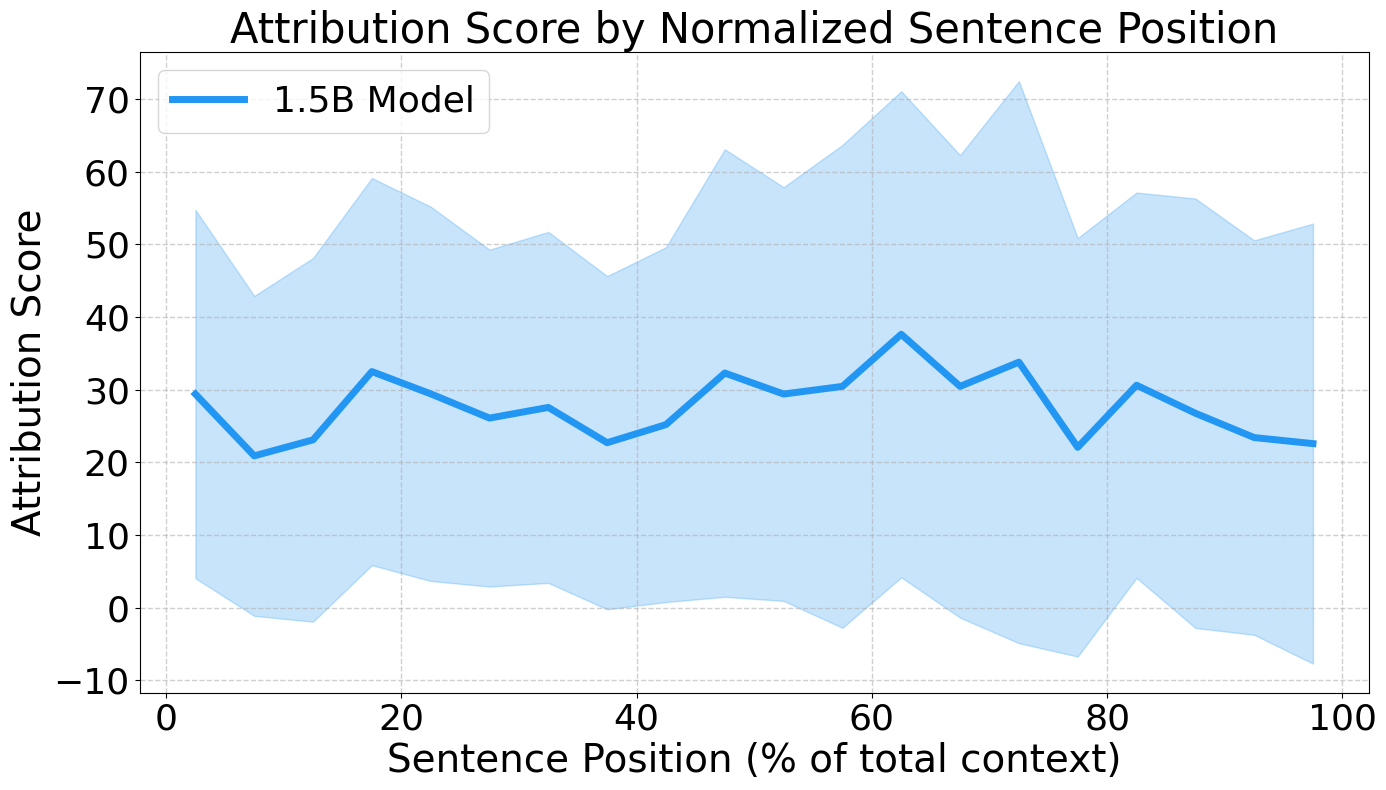

In [19]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Input folders
input_folder_1 = "Attribution Scores 1.5B Original"
input_folder_2 = "Attribution Scores_14B"

def load_attribution_scores(input_folder, label):
    qa_files = sorted([
        f for f in os.listdir(input_folder)
        if f.endswith(".csv") and f.startswith("MedBullets_df_op4_Q")
    ])
    all_percent_scores = []

    for filename in qa_files:
        filepath = os.path.join(input_folder, filename)
        try:
            df = pd.read_csv(filepath)
            if "Score" in df.columns and "sentence_ID" in df.columns:
                df = df[["sentence_ID", "Score"]].dropna()

                max_id = df["sentence_ID"].max()
                if max_id > 0:
                    df["percent_position"] = (df["sentence_ID"] / max_id) * 100
                    all_percent_scores.append(df[["percent_position", "Score"]])
            else:
                print(f"⚠️ Skipped {filename} (missing Score or sentence_ID)")
        except Exception as e:
            print(f"❌ Error in {filename}: {e}")

    if not all_percent_scores:
        print(f"🚫 No valid CSVs found in {input_folder} for {label}")
        return None, None

    combined_df = pd.concat(all_percent_scores)
    combined_df["percent_bin"] = pd.cut(combined_df["percent_position"], bins=np.linspace(0, 100, 21), include_lowest=True)
    bin_centers = combined_df["percent_bin"].apply(lambda b: b.mid)
    grouped = combined_df.groupby(bin_centers)["Score"]
    return grouped.mean(), grouped.std()

# Load and process each model
mean_1_5B, std_1_5B = load_attribution_scores(input_folder_1, "1.5B")
mean_14B, std_14B = load_attribution_scores(input_folder_2, "14B")

# Plot
plt.figure(figsize=(14, 8))

# Plot only if data is valid
if mean_1_5B is not None:
    x1 = mean_1_5B.index.values
    y1 = mean_1_5B.values
    err1 = std_1_5B.values
    plt.plot(x1, y1, color="#2196F3", label="1.5B Model", linewidth=5)
    plt.fill_between(x1, y1 - err1, y1 + err1, color="#2196F3", alpha=0.25)

if mean_14B is not None:
    x2 = mean_14B.index.values
    y2 = mean_14B.values
    err2 = std_14B.values
    plt.plot(x2, y2, color="#f5a525", label="14B Model", linewidth=5)
    plt.fill_between(x2, y2 - err2, y2 + err2, color="#f5a525", alpha=0.25)

plt.title("Attribution Score by Normalized Sentence Position", fontsize=30)
plt.xlabel("Sentence Position (% of total context)", fontsize=28)
plt.ylabel("Attribution Score", fontsize=28)
plt.grid(True, linestyle='--', linewidth=1, alpha=0.6)
plt.xticks(fontsize=26)
plt.yticks(fontsize=26)
plt.legend(fontsize=26)
plt.tight_layout()

plt.savefig("Attribution_Score_Comparison.pdf", format="pdf", dpi=300)
plt.show()


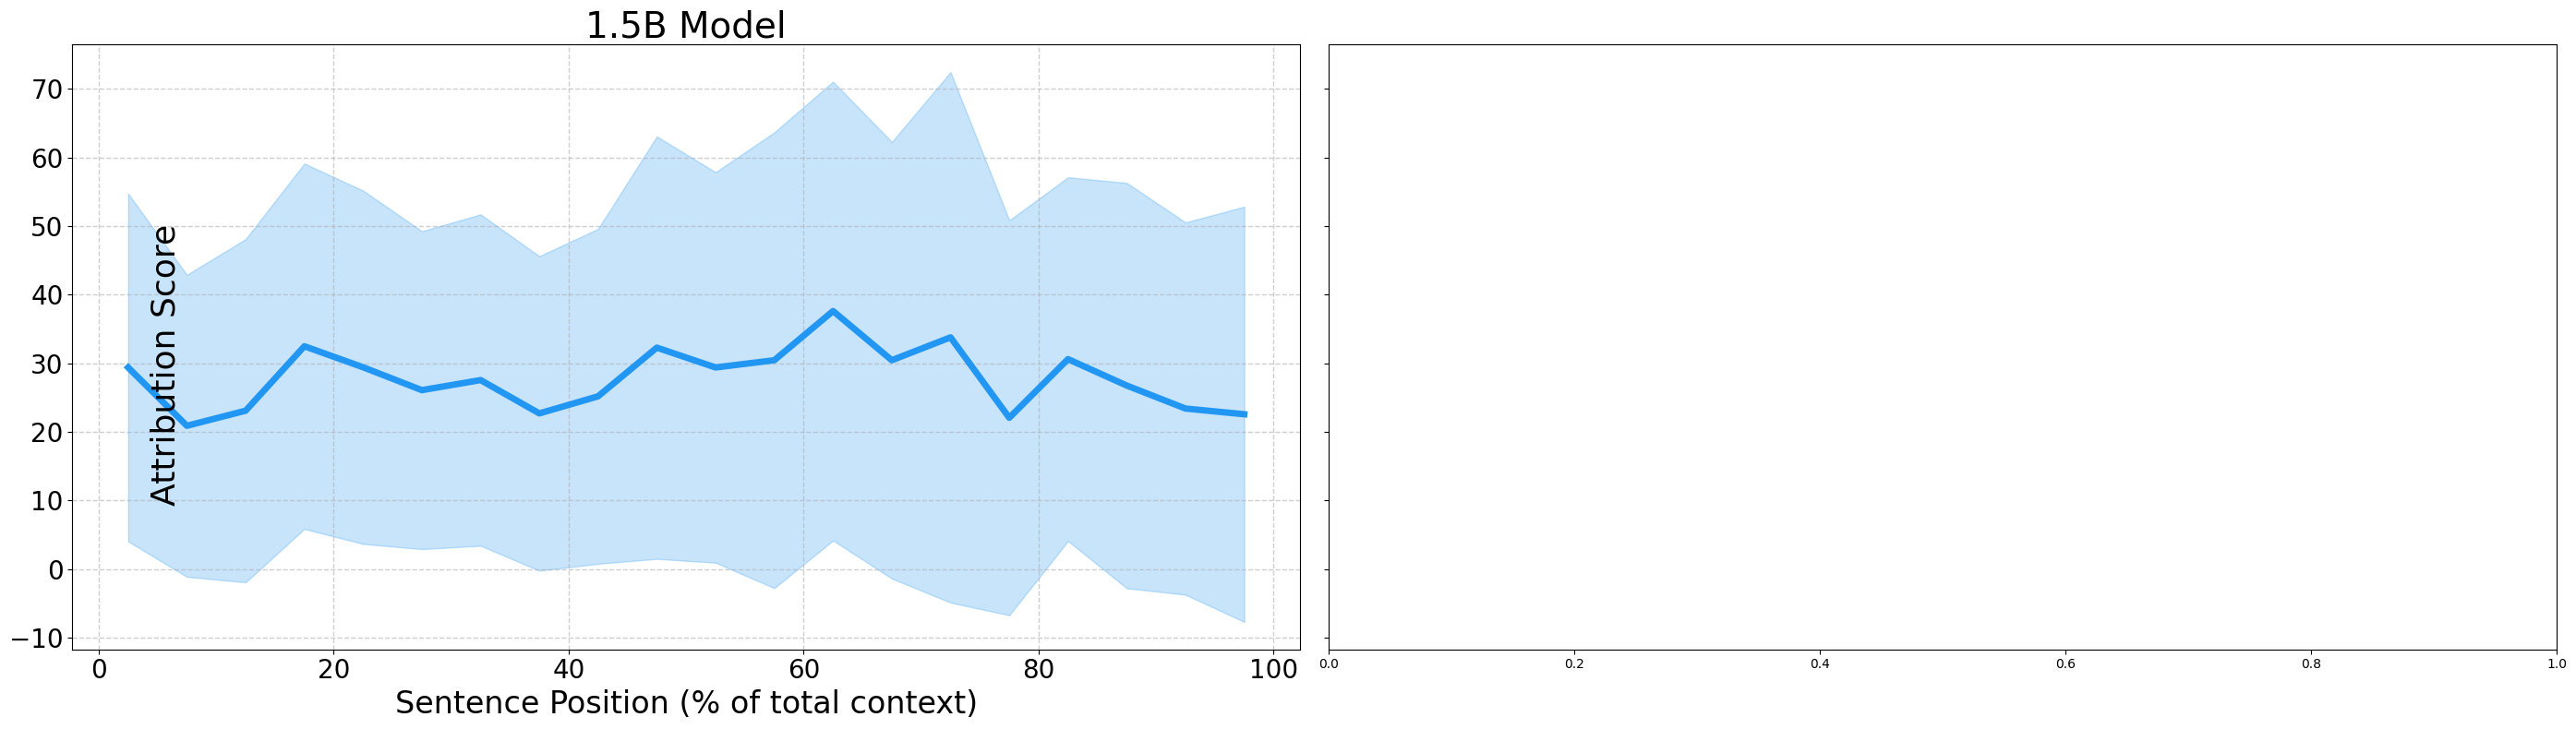

In [17]:
import matplotlib.pyplot as plt

# Create subplots
fig, axs = plt.subplots(1, 2, figsize=(28, 8), sharey=True)

# 1.5B Plot (Blue)
if mean_1_5B is not None:
    x1 = mean_1_5B.index.values
    y1 = mean_1_5B.values
    err1 = std_1_5B.values
    axs[0].plot(x1, y1, color="#2196F3", label="1.5B Model", linewidth=5)
    axs[0].fill_between(x1, y1 - err1, y1 + err1, color="#2196F3", alpha=0.25)
    axs[0].set_title("1.5B Model", fontsize=28)
    axs[0].set_xlabel("Sentence Position (% of total context)", fontsize=24)
    axs[0].grid(True, linestyle='--', linewidth=1, alpha=0.6)
    axs[0].tick_params(labelsize=20)

# 14B Plot (Orange)
if mean_14B is not None:
    x2 = mean_14B.index.values
    y2 = mean_14B.values
    err2 = std_14B.values
    axs[1].plot(x2, y2, color="#f5a525", label="14B Model", linewidth=5)
    axs[1].fill_between(x2, y2 - err2, y2 + err2, color="#f5a525", alpha=0.25)
    axs[1].set_title("14B Model", fontsize=28)
    axs[1].set_xlabel("Sentence Position (% of total context)", fontsize=24)
    axs[1].grid(True, linestyle='--', linewidth=1, alpha=0.6)
    axs[1].tick_params(labelsize=20)

# Shared Y label
fig.text(0.06, 0.5, 'Attribution Score', va='center', rotation='vertical', fontsize=26)

# Save and show
plt.tight_layout()
plt.savefig("Attribution_Score_Separated_Comparison.pdf", format="pdf", dpi=300)
plt.show()


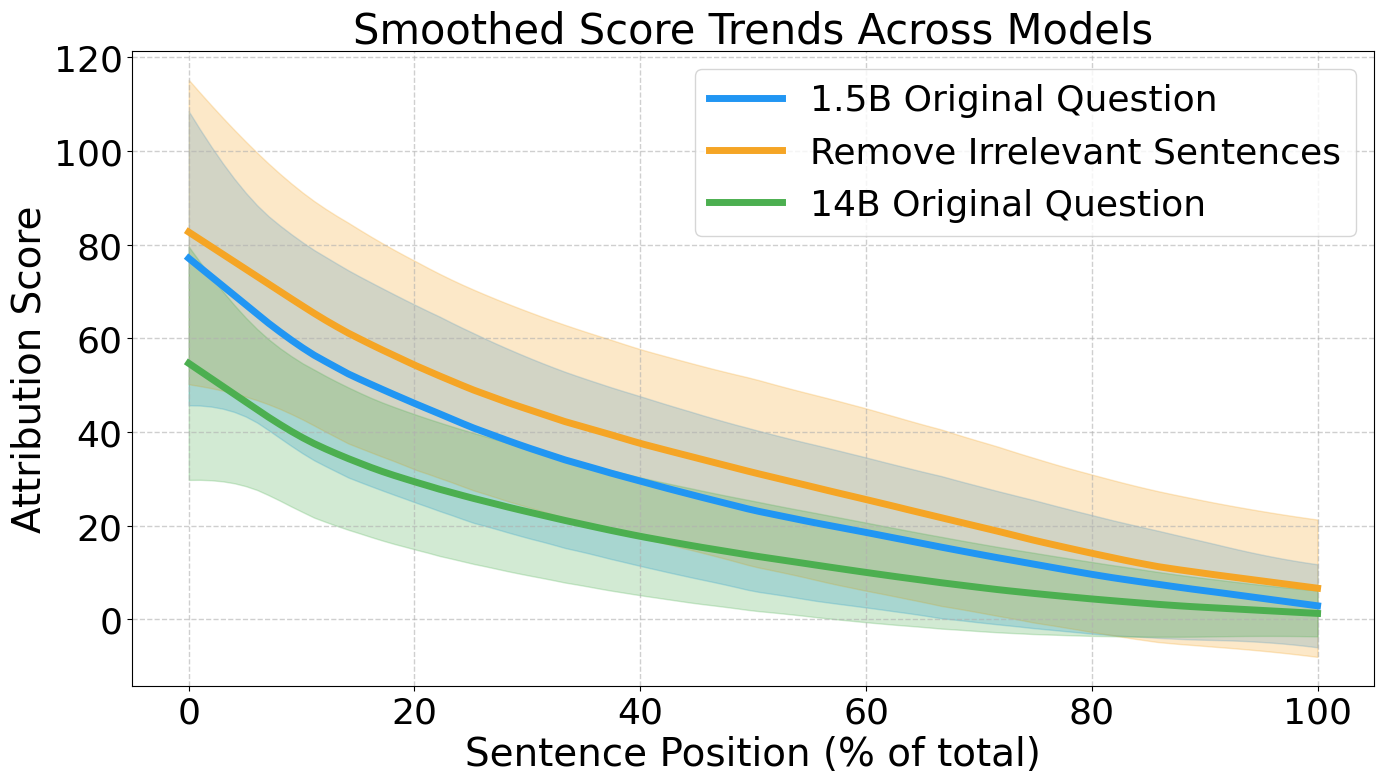

In [17]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Input folders
input_folder_1 = "Attribution Scores 1.5B Original"
input_folder_2 = "Attribution Scores 1.5 Final"
input_folder_3 = "Attribution Scores_14B"

# Get QA files that exist in all three folders
qa_files = sorted([
    f for f in os.listdir(input_folder_1)
    if f.endswith(".csv") and f.startswith("MedBullets_df_op4_Q")
    and os.path.exists(os.path.join(input_folder_2, f))
    and os.path.exists(os.path.join(input_folder_3, f))
])

def get_interpolated_matrix(folder):
    interpolated = []
    for filename in qa_files:
        filepath = os.path.join(folder, filename)
        try:
            df = pd.read_csv(filepath)
            if "Score" in df.columns:
                scores = df["Score"].dropna().values
                if len(scores) > 1:
                    interp = np.interp(np.linspace(0, len(scores) - 1, 100), np.arange(len(scores)), scores)
                    interpolated.append(interp)
        except Exception as e:
            print(f"❌ Error in {filepath}: {e}")
    return np.vstack(interpolated)

# Compute interpolated matrices
matrix_1 = get_interpolated_matrix(input_folder_1)
matrix_2 = get_interpolated_matrix(input_folder_2)
matrix_3 = get_interpolated_matrix(input_folder_3)

# Compute means and stds
mean_1, std_1 = matrix_1.mean(axis=0), matrix_1.std(axis=0)
mean_2, std_2 = matrix_2.mean(axis=0), matrix_2.std(axis=0)
mean_3, std_3 = matrix_3.mean(axis=0), matrix_3.std(axis=0)

x = np.linspace(0, 100, 100)

# Plot
plt.figure(figsize=(14, 8))

plt.plot(x, mean_1, color="#2196F3", label="1.5B Original Question", linewidth=5)
plt.fill_between(x, mean_1 - std_1, mean_1 + std_1, color="#2196F3", alpha=0.25)

plt.plot(x, mean_2, color="#f5a525", label="Remove Irrelevant Sentences", linewidth=5)
plt.fill_between(x, mean_2 - std_2, mean_2 + std_2, color="#f5a525", alpha=0.25)

plt.plot(x, mean_3, color="#4CAF50", label="14B Original Question", linewidth=5)
plt.fill_between(x, mean_3 - std_3, mean_3 + std_3, color="#4CAF50", alpha=0.25)

# Formatting
plt.title("Smoothed Score Trends Across Models", fontsize=30)
plt.xlabel("Sentence Position (% of total)", fontsize=28)
plt.ylabel("Attribution Score", fontsize=28)
plt.grid(True, linestyle='--', linewidth=1, alpha=0.6)
plt.xticks(fontsize=26)
plt.yticks(fontsize=26)
plt.legend(fontsize=26)
plt.tight_layout()
plt.show()
